# 📊 Notebook 01: Exploratory Data Analysis (EDA)

**Objective:** Understand the structure, quality, and patterns of the NVIDIA stock data (2016-2026) before attempting any modeling.

**Key Steps:**
1. Load data using the production `NVDADataLoader`.
2. Visualize price and volume trends.
3. Analyze distribution of returns.
4. Check for obvious anomalies.

In [10]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path to import src
sys.path.append(os.path.abspath('..'))

from src.data.loader import NVDADataLoader

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 7)

## 1. Load and Validate Data
We use the production loader to ensure we are looking at the same data the model will see.

In [11]:
DATA_PATH = '../data/raw/NVDA_yfinance_clean.csv'

# Initialize loader
loader = NVDADataLoader(DATA_PATH)

# Load with validation and run a full quality audit
# The `verbose=True` flag prints a detailed report.
df, report = loader.load_and_validate(verbose=True)

# --- Display the first few rows to confirm ---
df.head()


✅ Loaded 2,514 rows from NVDA_yfinance_clean.csv

                             📊 DATA QUALITY REPORT                              

📏 Dimensions: 2,514 rows × 6 columns
📅 Date Range: 2016-01-04 to 2025-12-31
🔢 Duplicate Rows: 0
❓ Total Missing Values: 0

--------------------------------------------------------------------------------
✅ VALIDATION PASSED - Data quality is excellent!



,Date,Close,High,Low,Open,Volume
0,2016-01-04,0.789588,0.794710,0.781538,0.787636,358076000
1,2016-01-05,0.802272,0.815688,0.792759,0.804467,490272000
2,2016-01-06,0.769098,0.792759,0.760073,0.789100,449344000
3,2016-01-07,0.738607,0.754950,0.728850,0.749828,645304000
4,2016-01-08,0.722752,0.748852,0.721289,0.748120,398472000


## 2. Price History Analysis
Visualizing the Close price to understand the trend.

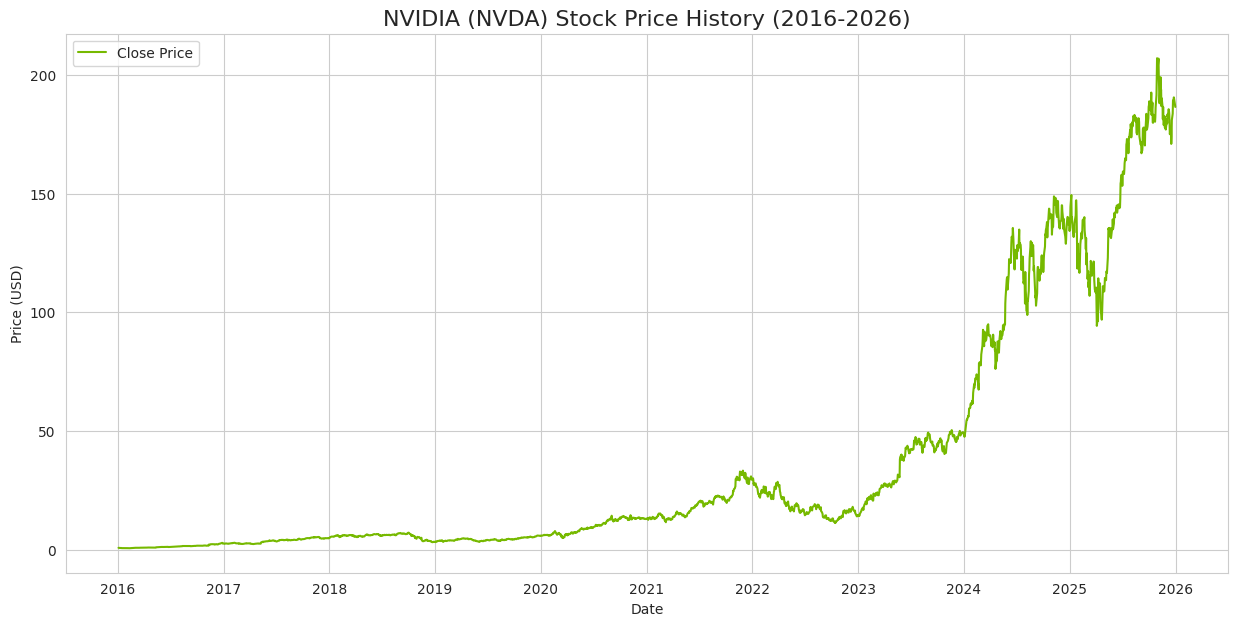

In [13]:
# --- Visualize the primary signal: Closing Price ---
plt.figure(figsize=(15, 7))
plt.plot(df['Date'], df['Close'], label='Close Price', color='#76b900') # NVIDIA Green
plt.title('NVIDIA (NVDA) Stock Price History (2016-2026)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## 3. Volume Analysis
Trading volume indicates market activity and liquidity.

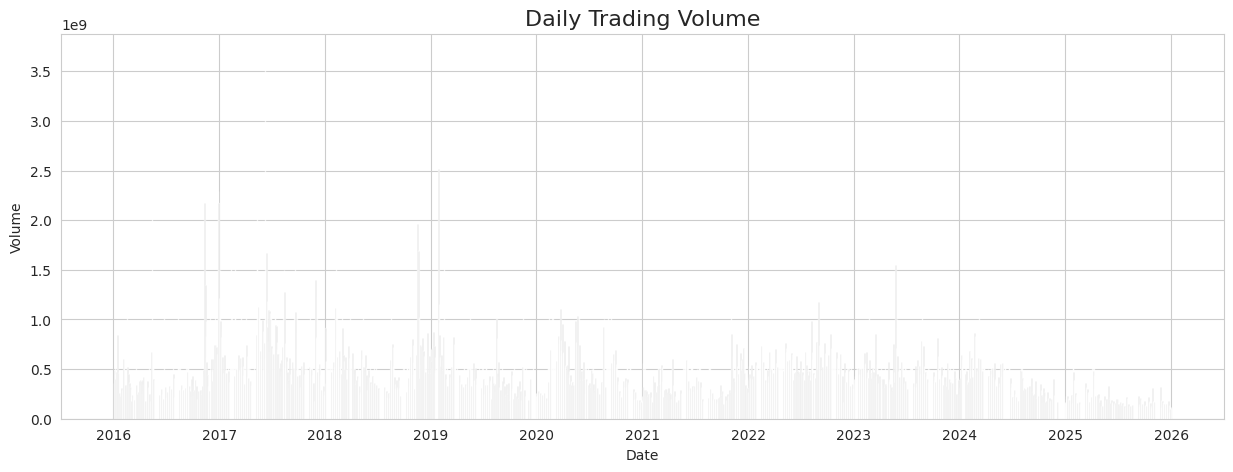

In [14]:
plt.figure(figsize=(15, 5))
plt.bar(df['Date'], df['Volume'], color='gray', alpha=0.7)
plt.title('Daily Trading Volume', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

## 4. Returns Distribution
Calculating daily returns to check for normality and outliers. This is crucial for statistical models.

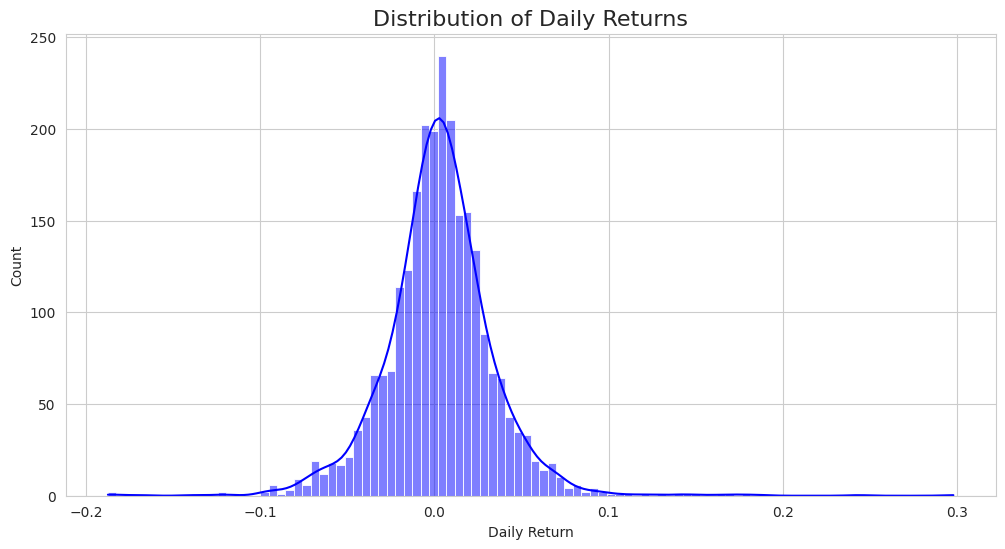

Mean Return: 0.0027
Std Dev: 0.0314
Min Return: -0.1876
Max Return: 0.2981


In [5]:
# Calculate daily returns
df['Daily_Return'] = df['Close'].pct_change()

plt.figure(figsize=(12, 6))
sns.histplot(df['Daily_Return'].dropna(), bins=100, kde=True, color='blue')
plt.title('Distribution of Daily Returns', fontsize=16)
plt.xlabel('Daily Return')
plt.show()

print(f"Mean Return: {df['Daily_Return'].mean():.4f}")
print(f"Std Dev: {df['Daily_Return'].std():.4f}")
print(f"Min Return: {df['Daily_Return'].min():.4f}")
print(f"Max Return: {df['Daily_Return'].max():.4f}")

## 5. Conclusion
Summary of findings from EDA.
### Q1: What is OHLCV Data?
In financial markets, **OHLCV** stands for **Open, High, Low, Close, Volume**.
* **Open**: The price at which the stock started trading when the market opened.
* **High**: The highest price reached during the trading day.
* **Low**: The lowest price reached during the trading day.
* **Close**: The final price when the market closed. This is the most critical data point for daily analysis and is used for calculating returns.
* **Volume**: The total number of shares traded. High volume often confirms the strength of a trend.

### Q2: Data Quality Checks
Checking for missing values and confirming the date range.

In [6]:
# Date Range
print(f"📅 Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"⏱️ Total Trading Days: {len(df)}")

# Missing Values Check
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values found in the dataset.")
else:
    print("⚠️ Missing values found:")
    print(missing[missing > 0])

📅 Date Range: 2016-01-04 to 2025-12-31
⏱️ Total Trading Days: 2514
⚠️ Missing values found:
Daily_Return    1
dtype: int64


### Visualization 1: Trend Analysis (Moving Averages)
We plot the **50-day** (Short-term) and **200-day** (Long-term) Simple Moving Averages (SMA). 
* **Golden Cross**: When 50-day crosses *above* 200-day (Bullish signal).
* **Death Cross**: When 50-day crosses *below* 200-day (Bearish signal).

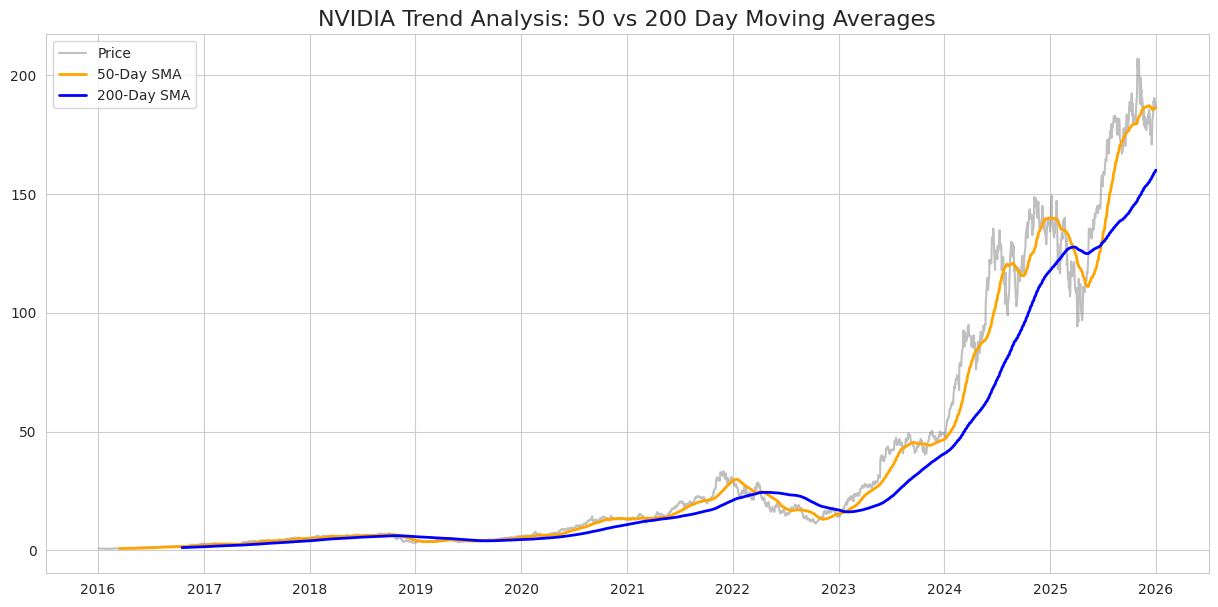

In [7]:
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(15, 7))
plt.plot(df['Date'], df['Close'], label='Price', alpha=0.5, color='gray')
plt.plot(df['Date'], df['SMA_50'], label='50-Day SMA', color='orange', linewidth=2)
plt.plot(df['Date'], df['SMA_200'], label='200-Day SMA', color='blue', linewidth=2)
plt.title('NVIDIA Trend Analysis: 50 vs 200 Day Moving Averages', fontsize=16)
plt.legend()
plt.show()

### Visualization 2: Volatility Analysis (Risk)
We calculate the **30-day rolling standard deviation** of returns. Spikes indicate periods of high uncertainty/risk.

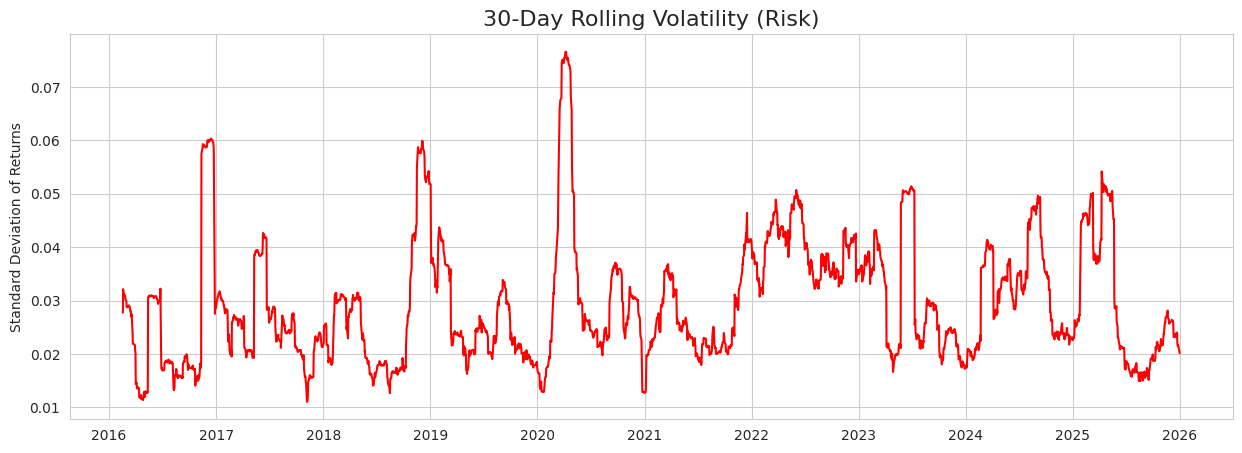

In [8]:
df['Volatility_30d'] = df['Daily_Return'].rolling(window=30).std()

plt.figure(figsize=(15, 5))
plt.plot(df['Date'], df['Volatility_30d'], color='red')
plt.title('30-Day Rolling Volatility (Risk)', fontsize=16)
plt.ylabel('Standard Deviation of Returns')
plt.show()

### Visualization 3: Monthly Seasonality
Are there specific months where NVIDIA tends to perform better? We extract the month and visualize the distribution of returns.

/tmp/ipykernel_16071/3985853862.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='Daily_Return', data=df, order=months_order, palette='viridis')


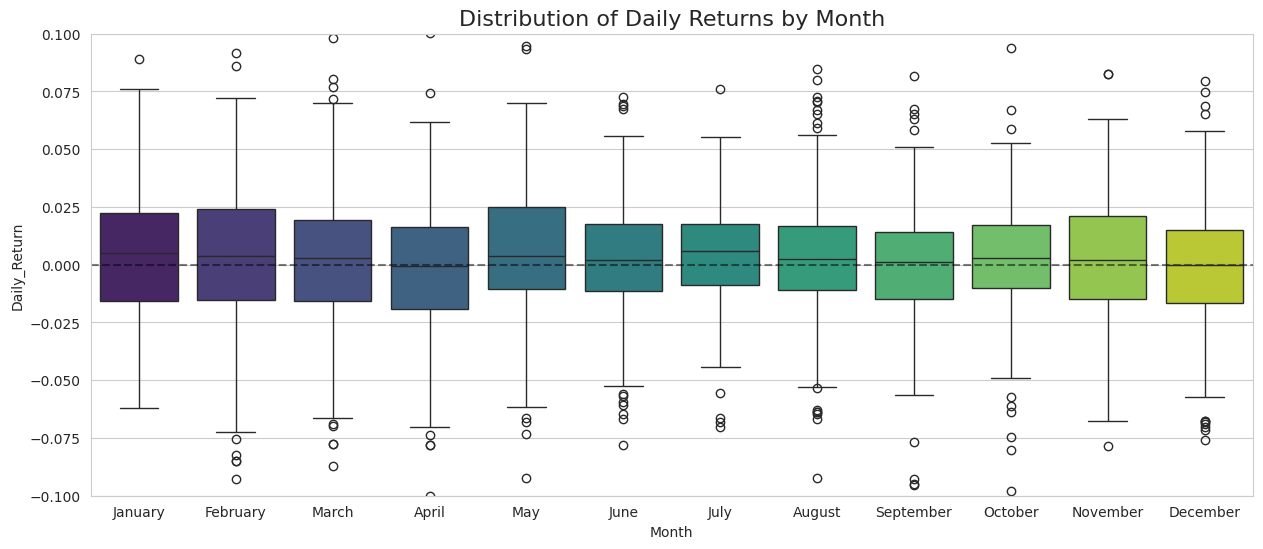

In [9]:
df['Month'] = df['Date'].dt.month_name()
# Order months correctly
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(15, 6))
sns.boxplot(x='Month', y='Daily_Return', data=df, order=months_order, palette='viridis')
plt.title('Distribution of Daily Returns by Month', fontsize=16)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.ylim(-0.1, 0.1) # Zoom in to see the boxes clearly
plt.show()

## 6. Conclusion & Insights
1. **Trend**: NVIDIA shows exponential growth, particularly in the post-2023 AI boom.
2. **Volatility**: Risk is not constant; it clusters around major market events (e.g., 2020 crash, 2022 correction).
3. **Seasonality**: The boxplot reveals if certain months have higher median returns or wider variance (risk).
4. **Data Quality**: The dataset is clean with no missing values in the core OHLCV columns, making it ready for feature engineering.